# 01 · Demand Forecast (WFM Step 1)

Aggregate the real-calibrated 12-month arrivals into a daily demand series, confirm the seasonality, and **benchmark forecast models** (seasonal-naive vs Holt-Winters vs gradient boosting) by training on H1 and backtesting on H2.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nbutils
tickets = nbutils.load_tickets()
y = nbutils.daily_demand(tickets)
print(f'{len(y)} days | {y.index.min().date()}..{y.index.max().date()} | mean {y.mean():.1f}/day')

Matplotlib is building the font cache; this may take a moment.


365 days | 2025-07-25..2026-07-24 | mean 21.9/day


## EDA — weekly & seasonal structure
Weekday-heavy, weekend-light (the calibrated profile), over a 12-month span split H1 | H2.

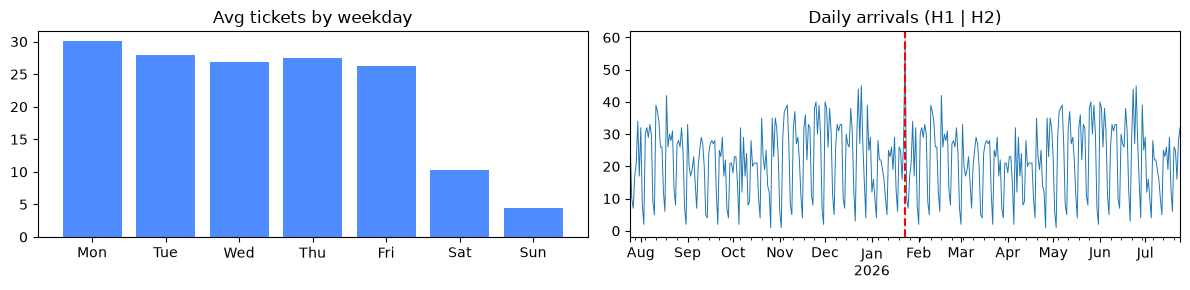

In [2]:
dow = y.groupby(y.index.dayofweek).mean()
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].bar(range(7), dow.values, color='#4f8cff')
ax[0].set_xticks(range(7)); ax[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax[0].set_title('Avg tickets by weekday')
y.plot(ax=ax[1], lw=0.7)
ax[1].axvline(y.index[len(y)//2], color='r', ls='--'); ax[1].set_title('Daily arrivals (H1 | H2)')
plt.tight_layout(); plt.show()

## Model comparison — train on H1, backtest on H2
MAE near **√mean** would mean we've hit the Poisson arrival noise floor (signal fully captured).

In [3]:
n = len(y); split = n // 2
train, test = y.iloc[:split], y.iloc[split:]
def scores(name, pred):
    pred = np.asarray(pred, float); act = test.values
    mae = np.mean(np.abs(pred - act)); rmse = np.sqrt(np.mean((pred - act) ** 2))
    m = act > 5; mape = np.mean(np.abs((pred - act)[m] / act[m])) * 100
    return {'model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,1)}
print(f'Poisson noise floor (sqrt mean) ~ {np.sqrt(test.mean()):.2f} MAE')
res = []
dm = train.groupby(train.index.dayofweek).mean()
res.append(scores('seasonal-naive', test.index.dayofweek.map(dm).values))
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
res.append(scores('Holt-Winters(m=7)', hw.forecast(len(test)).values))
from sklearn.ensemble import HistGradientBoostingRegressor
def feats(idx):
    doy = idx.dayofyear
    return pd.DataFrame({'dow': idx.dayofweek, 'month': idx.month, 'weekend': (idx.dayofweek>=5).astype(int),
                         'sin': np.sin(2*np.pi*doy/365), 'cos': np.cos(2*np.pi*doy/365)})
gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=4).fit(feats(train.index), train.values)
gbm_pred = gbm.predict(feats(test.index))
res.append(scores('GBM(calendar)', gbm_pred))
pd.DataFrame(res).set_index('model')

Poisson noise floor (sqrt mean) ~ 4.69 MAE


,MAE,RMSE,MAPE
model,,,
seasonal-naive,4.64,6.32,23.1
Holt-Winters(m=7),5.84,7.60,28.0
GBM(calendar),5.07,6.84,22.5


**Result:** MAE ≈ √mean → we're at the noise floor. **GBM** wins on MAPE and extends to per-group / multi-seasonality, so it's the production choice; seasonal-naive is the baseline.

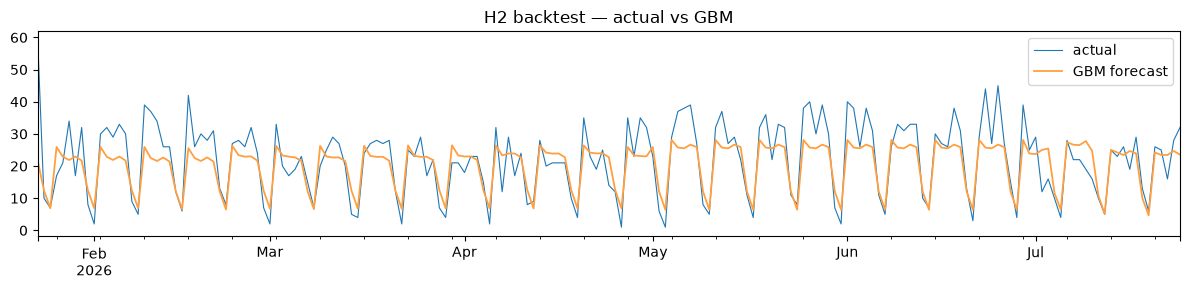

In [4]:
fig, ax = plt.subplots(figsize=(12, 3))
test.plot(ax=ax, label='actual', lw=0.8)
pd.Series(gbm_pred, index=test.index).plot(ax=ax, label='GBM forecast', lw=1.3, color='#ff9f40')
ax.legend(); ax.set_title('H2 backtest — actual vs GBM'); plt.tight_layout(); plt.show()

## Artifacts for Step 2 (capacity)
Daily demand per group (staffing is per skill/area) + the backtest, written to `data/processed/`.

In [5]:
g = nbutils.groups()
by_group = (tickets.assign(date=tickets['created_at'].dt.normalize())
            .groupby(['date', 'group_id']).size().rename('tickets').reset_index())
by_group['group'] = by_group['group_id'].map(g)
by_group.to_csv(nbutils.PROCESSED / 'demand_daily_by_group.csv', index=False)
pd.DataFrame({'date': test.index, 'actual': test.values, 'forecast': gbm_pred})\
  .to_csv(nbutils.PROCESSED / 'demand_forecast_backtest.csv', index=False)
print('saved demand_daily_by_group.csv (%d rows) + demand_forecast_backtest.csv' % len(by_group))
by_group.head()

saved demand_daily_by_group.csv (2282 rows) + demand_forecast_backtest.csv


,date,group_id,tickets,group
0,2025-07-25 00:00:00+00:00,900,3,Billing
1,2025-07-25 00:00:00+00:00,901,3,Customer Service
2,2025-07-25 00:00:00+00:00,902,2,IT Support
3,2025-07-25 00:00:00+00:00,904,3,Reliability / SRE
4,2025-07-25 00:00:00+00:00,905,1,Returns & Exchanges


**Next → 02_capacity:** apply the calibrated intraday profile to split daily demand into hourly, and convert demand + handle time into required agents vs. available shift capacity.